# Does document structure improve retrieval?

## An independent one-book reproduction of STAIR

This notebook reports a controlled comparison of BM25, NV-Embed-v2,
DSI, and a Table-of-Contents-conditioned STAIR retriever on *The Whole
Child*. All methods use the same frozen, leakage-safe test split of
1,758 generated questions and 129 candidate leaves.

The headline result is deliberately not simplified: STAIR does not
beat DSI overall in this reproduction, but it strongly improves
retrieval for depth-2 sections. Its deficit is concentrated in
depth-3 leaves and leaves absent from development.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
RESULTS_PATH = ROOT / "results/whole-child-results.json"
FIGURE_DIR = ROOT / "reports/figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
metrics = payload["metrics"]
paired = payload["paired_dsi_vs_stair"]

print(f"Loaded frozen results from {RESULTS_PATH}")
print(f"Source commit: {payload['git_commit']}")


Loaded frozen results from ../results/whole-child-results.json
Source commit: e42edce3d4f67b2187bd5d5dc69a774c6c0550df


## Experimental design

The source PDF contains 181 native ToC nodes. After excluding
front/back matter and a metadata-only media-attribution leaf, the
retrieval corpus contains 129 chapter-scoped leaf sections.

Questions generated from the same semantic source unit are assigned
to one split as a group. This prevents near-duplicate questions from
the same paragraph leaking between training and evaluation. The final
split contains 1,064 training, 392 development, and 1,758 test
questions. Every leaf occurs in training; 66 occur in development and
86 in test.

DSI and STAIR use the same Mistral-7B-Instruct-v0.2 checkpoint, LoRA
configuration, training questions, five-epoch budget, and constrained
candidate set. DSI receives only the query and emits an opaque leaf
ID. STAIR receives the complete ToC plus the query and emits the full
canonical path.


In [2]:
names = {
    "bm25": "BM25",
    "nvembed": "NV-Embed-v2",
    "dsi": "DSI",
    "stair": "STAIR",
}

rows = [
    "| Retriever | Recall@1 | Recall@3 | Recall@5 | nDCG@3 | Macro leaf Recall@1 |",
    "|---|---:|---:|---:|---:|---:|",
]

for key in ("bm25", "nvembed", "dsi", "stair"):
    row = metrics[key]
    rows.append(
        f"| {names[key]} | {row['recall_at_1']:.4f} | "
        f"{row['recall_at_3']:.4f} | {row['recall_at_5']:.4f} | "
        f"{row['ndcg_at_3']:.4f} | "
        f"{row['macro_leaf_recall_at_1']:.4f} |"
    )

display(Markdown("\n".join(rows)))


| Retriever | Recall@1 | Recall@3 | Recall@5 | nDCG@3 | Macro leaf Recall@1 |
|---|---:|---:|---:|---:|---:|
| BM25 | 0.7986 | 0.9107 | 0.9357 | 0.8648 | 0.7999 |
| NV-Embed-v2 | 0.6553 | 0.8271 | 0.8697 | 0.7553 | 0.7535 |
| DSI | 0.4010 | 0.5228 | 0.5830 | 0.4716 | 0.3957 |
| STAIR | 0.3754 | 0.4812 | 0.4994 | 0.4373 | 0.3295 |

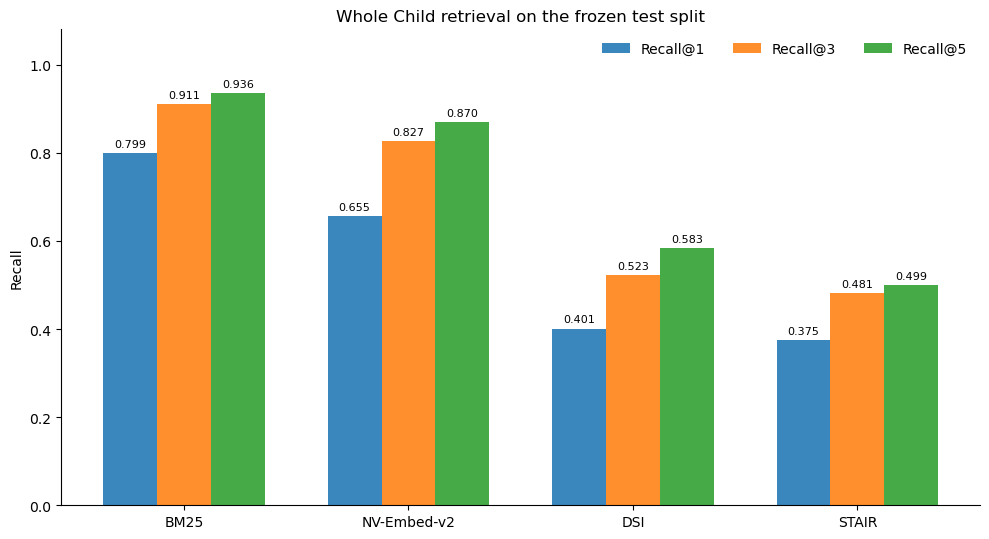

In [3]:
keys = ["bm25", "nvembed", "dsi", "stair"]
labels = [names[key] for key in keys]
x = np.arange(len(keys))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5.5))

for offset, (metric, label) in enumerate(
    (
        ("recall_at_1", "Recall@1"),
        ("recall_at_3", "Recall@3"),
        ("recall_at_5", "Recall@5"),
    )
):
    values = [metrics[key][metric] for key in keys]
    bars = ax.bar(
        x + (offset - 1) * width,
        values,
        width,
        label=label,
        alpha=0.88,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_title("Whole Child retrieval on the frozen test split")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.08)
ax.set_xticks(x, labels)
ax.legend(frameon=False, ncol=3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "retriever-recall.png", dpi=180)
plt.show()


## The primary comparison

DSI reaches 0.4010 Recall@1 and STAIR reaches 0.3754, a difference of
-0.0256 for STAIR. Across the paired test queries, both methods are
correct on 421, DSI alone on 284, STAIR alone on 239, and neither on
814.

The exact two-sided McNemar p-value is 0.0543. A 10,000-sample paired
bootstrap gives a 95% interval of [-0.0506, 0.0000] for STAIR minus
DSI. The point estimate favors DSI, but the difference narrowly misses
the conventional 0.05 significance threshold.


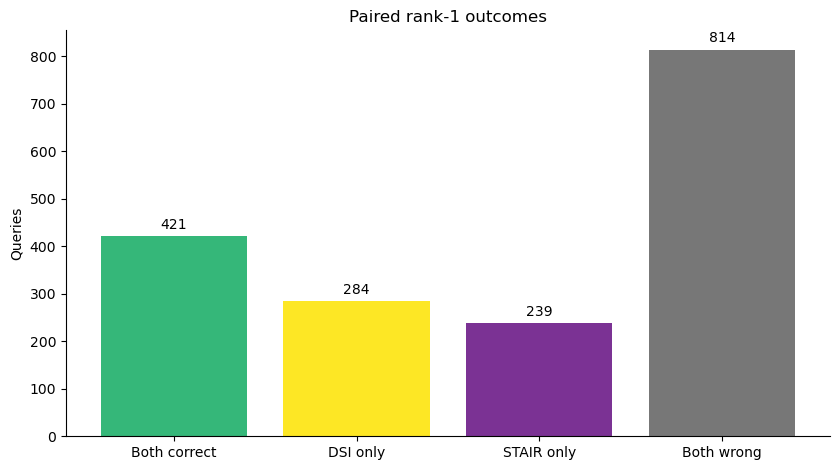

In [4]:
outcomes = paired["outcomes"]
outcome_names = ["Both correct", "DSI only", "STAIR only", "Both wrong"]
outcome_keys = ["both_correct", "dsi_only", "stair_only", "both_wrong"]
values = [outcomes[key] for key in outcome_keys]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    outcome_names,
    values,
    color=["#35b779", "#fde725", "#7b3294", "#777777"],
)
ax.bar_label(bars, padding=3)
ax.set_title("Paired rank-1 outcomes")
ax.set_ylabel("Queries")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "paired-rank-one-outcomes.png", dpi=180)
plt.show()


## Hierarchy depth reverses the result

STAIR is substantially better on depth-2 destinations: 0.5497 versus
DSI's 0.2853. That corresponds to roughly 101 additional correct
answers. At depth 3, however, STAIR falls to 0.3270 while DSI reaches
0.4331—roughly 146 fewer correct answers. Since depth-3 queries are the
majority, they reverse the aggregate outcome.

This is evidence for a narrower claim than the paper's headline:
explicit structure helps coarse routing in this experiment, but the
model does not reliably resolve deeper semantic paths.


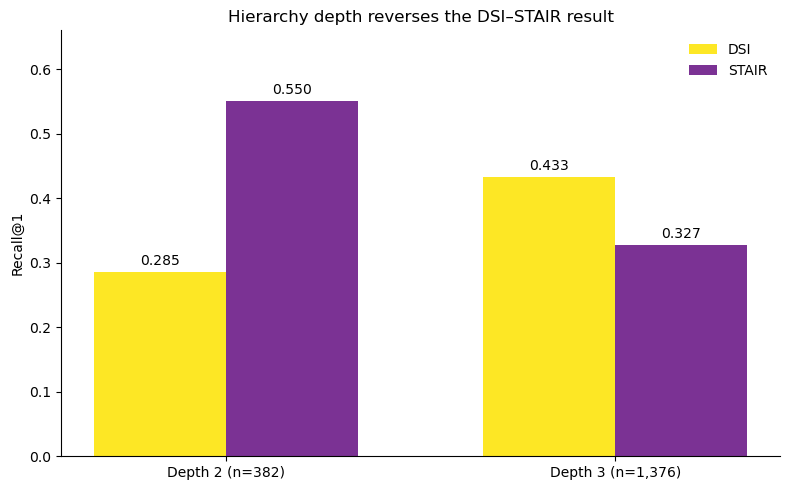

In [5]:
depth = paired["by_hierarchy_depth"]
x = np.arange(2)
width = 0.34
dsi = [depth["2"]["dsi_recall_at_1"], depth["3"]["dsi_recall_at_1"]]
stair = [depth["2"]["stair_recall_at_1"], depth["3"]["stair_recall_at_1"]]

fig, ax = plt.subplots(figsize=(8, 5))
dsi_bars = ax.bar(x - width / 2, dsi, width, label="DSI", color="#fde725")
stair_bars = ax.bar(x + width / 2, stair, width, label="STAIR", color="#7b3294")
ax.bar_label(dsi_bars, fmt="%.3f", padding=3)
ax.bar_label(stair_bars, fmt="%.3f", padding=3)
ax.set_title("Hierarchy depth reverses the DSI–STAIR result")
ax.set_ylabel("Recall@1")
ax.set_ylim(0, 0.66)
ax.set_xticks(x, ["Depth 2 (n=382)", "Depth 3 (n=1,376)"])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "dsi-stair-by-depth.png", dpi=180)
plt.show()


## Development coverage explains most of the aggregate gap

For 1,614 test questions whose gold leaves also occur in development,
DSI and STAIR are nearly tied at 0.4002 and 0.3916. For the remaining
144 questions, DSI reaches 0.4097 while STAIR falls to 0.1944. Those
144 questions are only 8.2% of the test set but account for about 31 of
DSI's total 45-query advantage.

The grouped split makes this limitation visible. Leaves with too few
independent source units cannot be represented in train, development,
and test without allowing passage-level leakage.


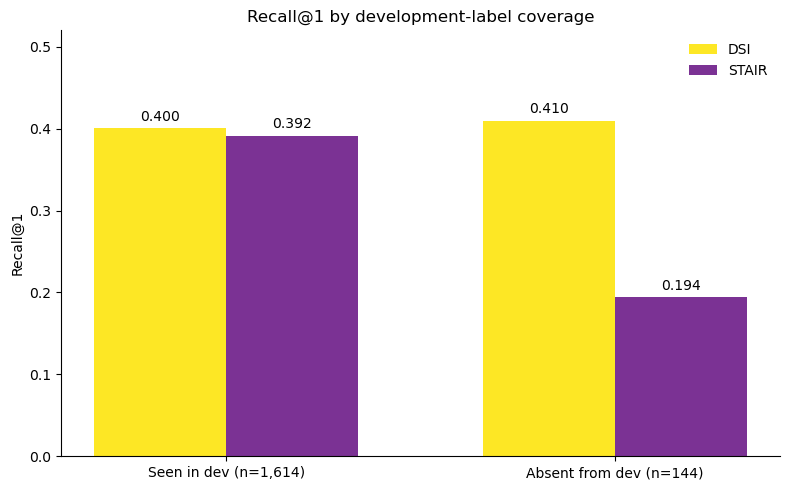

In [6]:
coverage = paired["by_development_leaf_coverage"]
groups = ["seen_in_dev", "absent_from_dev"]
x = np.arange(2)
dsi = [coverage[key]["dsi_recall_at_1"] for key in groups]
stair = [coverage[key]["stair_recall_at_1"] for key in groups]

fig, ax = plt.subplots(figsize=(8, 5))
dsi_bars = ax.bar(x - width / 2, dsi, width, label="DSI", color="#fde725")
stair_bars = ax.bar(x + width / 2, stair, width, label="STAIR", color="#7b3294")
ax.bar_label(dsi_bars, fmt="%.3f", padding=3)
ax.bar_label(stair_bars, fmt="%.3f", padding=3)
ax.set_title("Recall@1 by development-label coverage")
ax.set_ylabel("Recall@1")
ax.set_ylim(0, 0.52)
ax.set_xticks(x, ["Seen in dev (n=1,614)", "Absent from dev (n=144)"])
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "dsi-stair-by-dev-coverage.png", dpi=180)
plt.show()


## Operational cost

The complete ToC is 1,603 tokens before adding the query and generation
prompt. Repeating it for every request makes STAIR much more expensive
than DSI. On the same L40S, five-beam DSI decoding averaged 69.4 ms per
query and peaked at 16.24 GiB. STAIR averaged 2.17 seconds per query and
peaked at 36.92 GiB.

NV-Embed query encoding itself was fast, but a cold checkpoint load
from the reattached EBS volume took 45.5 minutes. One-off benchmark
latency can therefore be dominated by storage rather than inference.


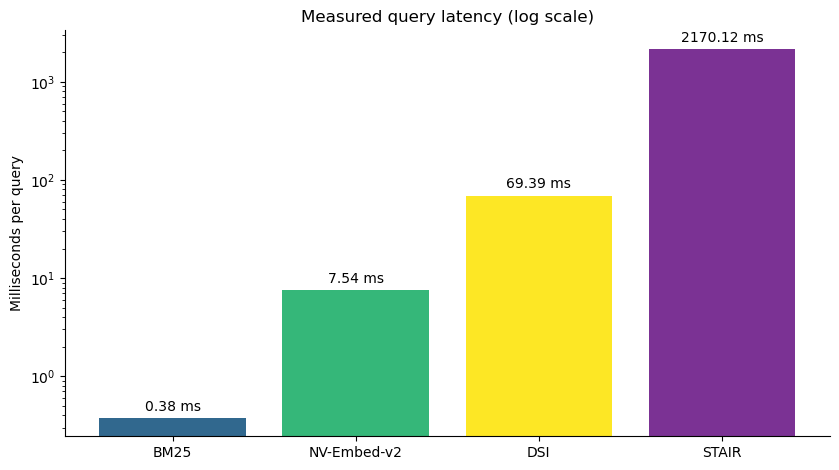

In [7]:
latency = [metrics[key]["milliseconds_per_query"] for key in keys]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    labels,
    latency,
    color=["#31688e", "#35b779", "#fde725", "#7b3294"],
)
ax.set_yscale("log")
ax.bar_label(bars, labels=[f"{value:.2f} ms" for value in latency], padding=3)
ax.set_title("Measured query latency (log scale)")
ax.set_ylabel("Milliseconds per query")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "retriever-latency.png", dpi=180)
plt.show()


## What this reproduction establishes

1. The paper's overall STAIR-over-DSI ordering was not reproduced on
   this independently reconstructed one-book test.
2. The observed DSI advantage is borderline rather than conventionally
   significant.
3. ToC conditioning has a large positive effect for depth-2 routing.
4. Deeper paths, low-resource leaves, and incomplete development-label
   coverage reverse that advantage.
5. STAIR's wrong depth-3 predictions are only slightly more local in
   the hierarchy, so the deficit is not merely a sibling near miss.

These findings do not invalidate the multi-book paper result. The
original released dataset was unavailable, the paper omits details
needed to reconstruct its question generator and split exactly, and
this reproduction uses a stricter passage-grouped split. The result is
best read as a boundary condition: structure can help, but hierarchy
depth, target representation, split design, and training budget decide
whether that help survives exact leaf retrieval.

A clean follow-up is a two-by-two ablation over input context (query
alone versus ToC plus query) and target representation (opaque ID
versus canonical path). That would isolate the value of the ToC from
the extra difficulty of generating a long path.
